In [ ]:
Hypothesis 1: The revelation of a Data-scandal leads to an abrupt increase in privacy-related Google search activity compared to the pre-event period.

In [1]:

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import mannwhitneyu
from scipy.stats import shapiro
from scipy.stats import norm

Search terms for action to scandal:


how_to_delete_Facebook

how_to_delete_Facebook_account

delete_Facebook

deactivate_Facebook 

Facebook_privacy_settings

Facebook_security_settings


In [2]:
path = [ "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/deactivate_Facebook.csv",
"/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/delete_Facebook_account.csv",
"/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/delete_Facebook.csv ",
"/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/Facebook_privacy_settings.csv",
"/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/Facebook_security_settings.csv",
"/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/how_to_delete_Facebook.csv",]


In [3]:

def loadcsv (path, col_name):
    df = pd.read_csv (path, skiprows = 1, names = ["date", col_name], index_col= "date")

    df[col_name]= pd.to_numeric (df[col_name], errors = "coerce")
    df.index = pd.to_datetime (df.index,errors = "coerce" )

    df = df.dropna().sort_index()
    return df

def add_csv_to_df(path, col_name, old_df):
    
    new_df = pd.read_csv(path, skiprows=1, names = ["date", col_name], index_col="date")
    new_df[col_name]= pd.to_numeric(new_df[col_name], errors = "coerce")
    new_df.index = pd.to_datetime(new_df.index,errors = "coerce" )
    new_df = new_df.dropna().sort_index()

    merged_df = pd.concat([old_df, new_df], axis = 1, join = "outer")
    merged_df.head()
    return merged_df
    

In [6]:
dfdeactivate_Facebook = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/deactivate_Facebook.csv","deactivate_Facebook"
)

dfdelete_Facebook_account = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/delete_Facebook_account.csv","delete_Facebook_account"
)

dfdelete_Facebook = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/delete_Facebook.csv","delete_Facebook"
)

dfFacebook_privacy_settings = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/Facebook_privacy_settings.csv","Facebook_privacy_settings"
)


dfFacebook_security_settings = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/Facebook_security_settings.csv","Facebook_security_settings"
)

dfhow_to_delete_Facebook = loadcsv (
    "/Users/janniella/Desktop/ProjectCSSFoundation/actiontoscandal/how_to_delete_Facebook.csv","how_to_delete_Facebook."
)

/var/folders/3f/l_wmv54906bdr5kvy25ldqdw0000gp/T/ipykernel_47395/966915858.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime (df.index,errors = "coerce" )
/var/folders/3f/l_wmv54906bdr5kvy25ldqdw0000gp/T/ipykernel_47395/966915858.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime (df.index,errors = "coerce" )
/var/folders/3f/l_wmv54906bdr5kvy25ldqdw0000gp/T/ipykernel_47395/966915858.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime (df.index,errors = "coerce" )
/var/folders/3f/l_wmv54906bdr5k

In [8]:
#using the mean interest across search terms
#keyword kurz mal rausgenommen wegen beschränkung auf mai, security settings

dfmerged = pd.concat (
    [dfdelete_Facebook,dfdeactivate_Facebook,dfdelete_Facebook_account,dfFacebook_privacy_settings,dfhow_to_delete_Facebook,dfFacebook_security_settings],
    axis = 1, join = 'inner'
)

dfmerged ["interest"]= dfmerged.mean(axis = 1)

dfmerged

,delete_Facebook,deactivate_Facebook,delete_Facebook_account,Facebook_privacy_settings,how_to_delete_Facebook.,Facebook_security_settings,interest
date,,,,,,,
2018-02-16,39.0,68.0,44.0,26.0,43.0,0.0,36.666667
2018-02-17,43.0,68.0,52.0,19.0,48.0,0.0,38.333333
2018-02-18,44.0,83.0,55.0,21.0,51.0,0.0,42.333333
2018-02-19,41.0,75.0,44.0,21.0,43.0,0.0,37.333333
2018-02-20,38.0,64.0,43.0,25.0,42.0,0.0,35.333333
...,...,...,...,...,...,...,...
2018-05-21,38.0,81.0,46.0,18.0,41.0,0.0,37.333333
2018-05-22,36.0,82.0,44.0,22.0,37.0,0.0,36.833333
2018-05-23,38.0,75.0,46.0,0.0,41.0,0.0,33.333333


In [9]:
scandalpublic = pd.Timestamp("2018-3-17")




pre_event14 = dfmerged.loc[scandalpublic - pd.Timedelta(days=14) : scandalpublic - pd.Timedelta(days=1)]
post_event14 = dfmerged.loc[scandalpublic : scandalpublic + pd.Timedelta(days=13)]

pre_event7 = dfmerged.loc[scandalpublic - pd.Timedelta(days=7) : scandalpublic - pd.Timedelta(days=1)]
post_event7 = dfmerged.loc[scandalpublic : scandalpublic + pd.Timedelta(days=6)]

print(len(pre_event14), len(post_event14))
print(len(pre_event7), len(post_event7))


14 14
7 7


In [13]:
diff14 = post_event14.values - pre_event14.values
diff7  = post_event7.values  - pre_event7.values

median_diff14 = np.median(diff14, axis=0)
median_diff7  = np.median(diff7,  axis=0)

print("Median paired difference (14 Tage):", median_diff14)
print("Median paired difference (7 Tage):", median_diff7)

Median paired difference (14 Tage): [41.         22.5        33.         30.         41.          0.
 32.16666667]
Median paired difference (7 Tage): [49.         14.         32.         23.         39.          0.
 30.16666667]


In [ ]:
pre14_agg  = pre_event14.median(axis=1).to_numpy()
post14_agg = post_event14.median(axis=1).to_numpy()

pre7_agg   = pre_event7.median(axis=1).to_numpy()
post7_agg  = post_event7.median(axis=1).to_numpy()


wilcoxon_14 = stats.wilcoxon(pre14_agg, post14_agg, alternative="two-sided")
wilcoxon_7  = stats.wilcoxon(pre7_agg,  post7_agg,  alternative="two-sided")

print("Wilcoxon 14 Tage:", wilcoxon_14)
print("Wilcoxon 7 Tage:", wilcoxon_7)


def r_from_p(p, n):
    z = abs(stats.norm.ppf(p / 2))   # two-sided
    return z / np.sqrt(n)

r14 = r_from_p(wilcoxon_14.pvalue, len(pre14_agg))
r7  = r_from_p(wilcoxon_7.pvalue,  len(pre7_agg))

print("Effect size r (14 Tage):", r14)
print("Effect size r (7 Tage):", r7)


median_diff14 = np.median(post14_agg - pre14_agg)
median_diff7  = np.median(post7_agg  - pre7_agg)

print("Median paired difference (14 Tage):", median_diff14)
print("Median paired difference (7 Tage):", median_diff7)


Wilcoxon 14 Tage: WilcoxonResult(statistic=np.float64(1.0), pvalue=np.float64(0.000244140625))
Wilcoxon 7 Tage: WilcoxonResult(statistic=np.float64(1.5), pvalue=np.float64(0.046875))
Effect size r (14 Tage): 0.9804022404852408
Effect size r (7 Tage): 0.7511771335493357
Median paired difference (14 Tage): 37.5
Median paired difference (7 Tage): 34.0


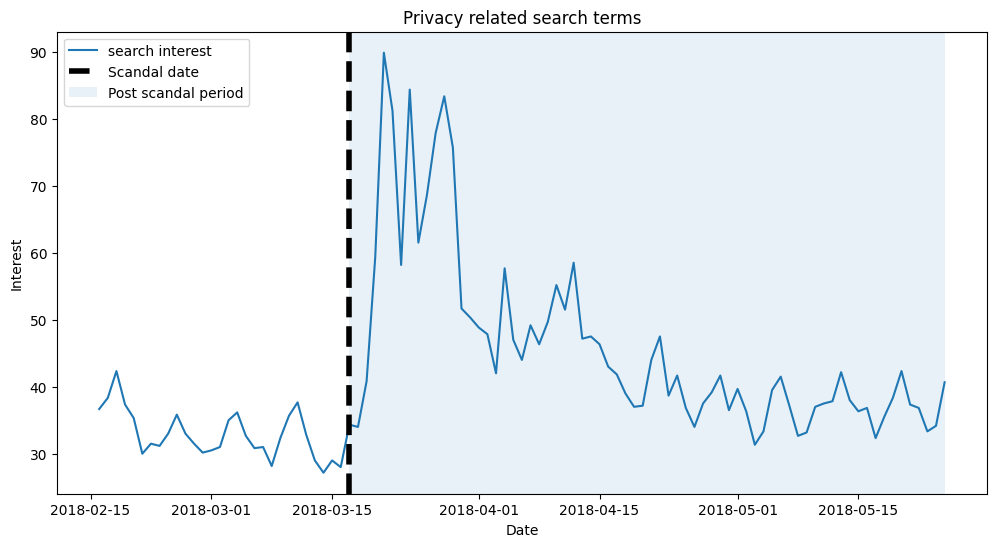

In [15]:
plt.figure(figsize = (12,6))
plt.plot(dfmerged.index, dfmerged["interest"], label = "search interest")

plt.axvline (scandalpublic, linewidth = 4, color = "black", linestyle = "--", label = "Scandal date")

plt.axvspan (
    scandalpublic, dfmerged.index.max(),alpha=0.1, label = "Post scandal period"
)

plt.title ("Privacy related search terms")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.legend()
plt.show()

## 